<a href="https://colab.research.google.com/github/Nicolas-Bernal/Simulacion-Estadistica/blob/main/Primer%20Corte/04_Metodo_aceptacion_y_rechazo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nicolas Alexander Bernal Rubio

## Simulacion Estadistica

# *Generacion De Variables Aleatorias *


In [35]:
install.packages("rmutil")
library(rmutil)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## Metodo Inversa (repaso)

$$f(x) \longrightarrow F(x) \longrightarrow U = F(x), \quad U \sim U(0,1)$$

$$\longrightarrow X = F^{-1}(U)$$

$$f(x) = \frac{1}{(b-a)} \mathbb{I}_{(a, b)} \quad \text{f.d.p. de } X \sim U(a, b)$$

*(Función Indicadora)*

$$F(x) = \int_{a}^{x} \frac{1}{(b-a)} dt = \frac{(x-a)}{(b-a)}$$

$$U = \frac{(x-a)}{(b-a)}$$

$$U(b-a) = x-a$$

$$U(b-a)+a = x$$





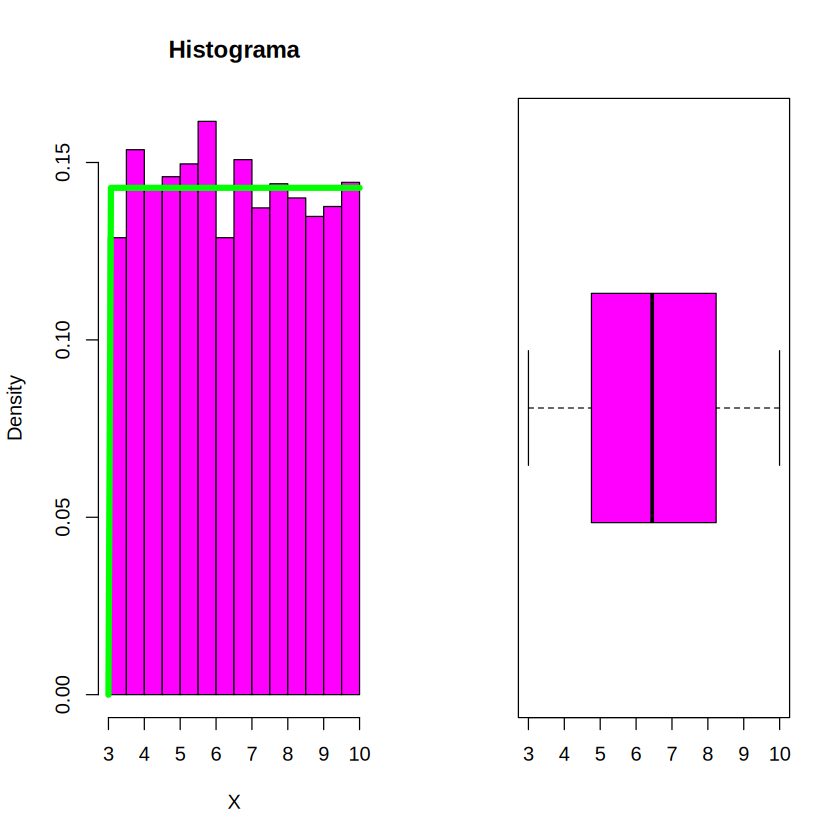

In [13]:
genunif = function(nsim,a,b){
  u = runif(nsim,0,1)
  x = u*(b-a)+a
  return(x)
}

X = genunif(5000,3,10)

par(mfrow = c(1,2))
hist(X,freq = FALSE,breaks = "FD",col = "magenta",main = "Histograma")
curve(dunif(x,3,10),add = TRUE,col = "green",lwd = 5)
boxplot(X,horizontal = TRUE,col = "magenta")

## Metodo de Aceptacion y Rechazo

* $f(x)$: función de interés
* $g(x)$: función auxiliar o instrumental
* $M$: constante

$$M = \max \left\{ \frac{f(x)}{g(x)} \right\}$$

$$f(x) \le g(x) \cdot M \quad \forall x$$

**Tasa de Aceptación:**

$$\text{Tasa de Aceptación} = \frac{\# \text{ de puntos que se aceptan}}{\# \text{ total de puntos}}$$



	Shapiro-Wilk normality test

data:  N
W = 0.99968, p-value = 0.6345


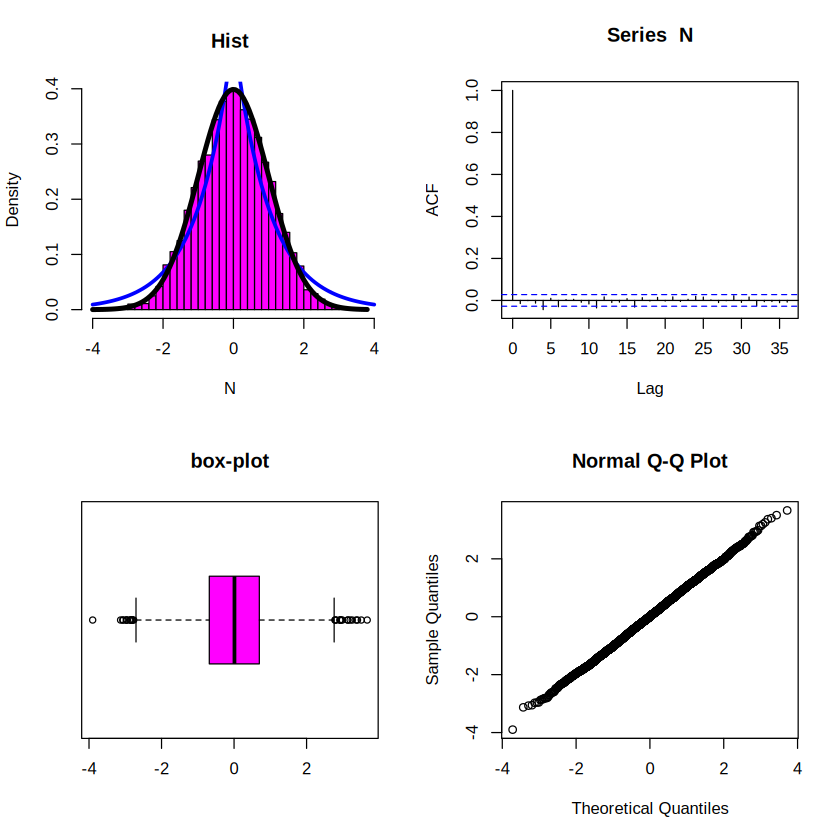

In [34]:


genNorm = function(nsim){
  k = 0
  j = 0
  M = 1.315489

  X = numeric(nsim)

  while(k < nsim){
    Y = rlaplace(1,0,1)
    U = runif(1,0,1)
    j = j + 1

    if (U <= dnorm(Y,0,1)/(dlaplace(Y,0,1)*M)){
      k = k + 1
      X[k] = Y
    }
  }
  return(X)
}

N = genNorm(5000)
par(mfrow = c(2,2))
hist(N,freq = FALSE,breaks = "FD",col = "magenta",main = "Hist")
curve(dlaplace(x,0,1),add = TRUE,from = -4,to = 4,lwd = 3,col = "blue")
curve(dnorm(x,0,1),add = TRUE,col = "black",lwd = 4)
acf(N)
boxplot(N,horizontal = TRUE,col = "magenta",main = "box-plot")
qqnorm(N)

shapiro.test(N)

## Ejemplo practico $#1$

### Enunciado

Generar números pseudoaleatorios de la función de interés y comprobar que efectivamente si se producen los números deseados a través de gráficas y pruebas analíticas.

$$f(y) = \frac{1}{\sqrt{2\pi}} e^{-y^2/2}, \quad y \in \mathbb{R}$$

usando como función auxiliar

$$g(y) = \frac{1}{2} e^{-|y|},$$

### Relacion de densidades

$$\frac{f(y)}{g(y)} = \frac{\frac{1}{\sqrt{2\pi}} e^{-y^2/2}}{\frac{1}{2} e^{-\vert{}y\vert{}}} = \sqrt{\frac{2}{\pi}} e^{\vert{}y\vert{} - \frac{y^2}{2}}$$

$$h(y) = \vert{}y\vert{} - \frac{y^2}{2}$$

$$\vert{}y\vert{} = 1$$

Evaluando en $\vert{}y\vert{} = 1$:$$M = \sqrt{\frac{2}{\pi}} e^{1 - 1/2} = \sqrt{\frac{2 e}{\pi}} \approx 1.315489$$


	Shapiro-Wilk normality test

data:  datos
W = 0.99976, p-value = 0.864


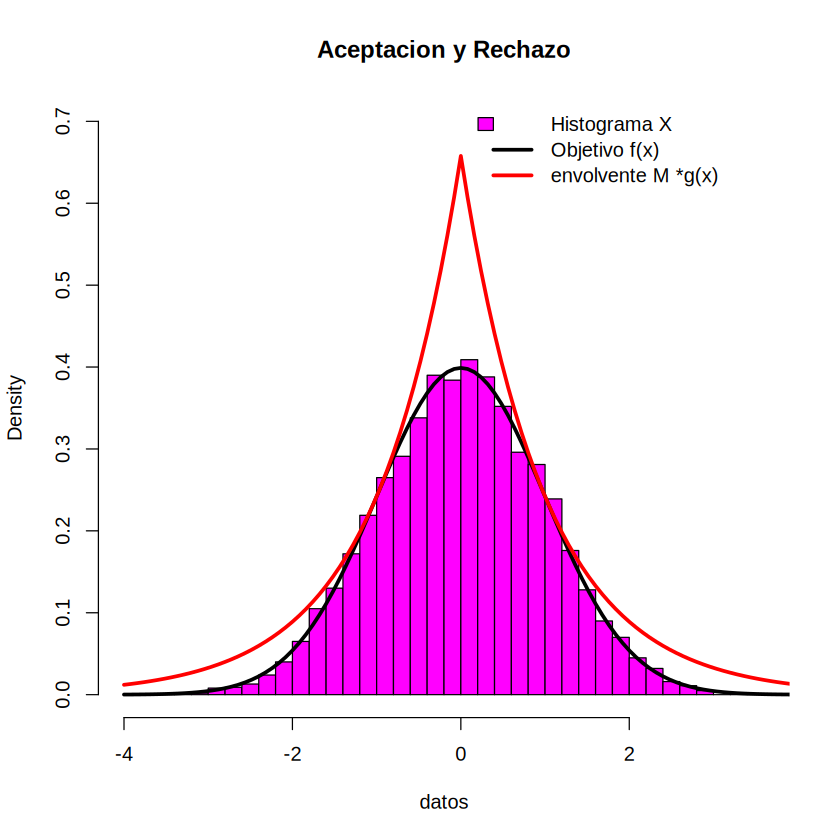

In [70]:

M = 1.315489

f_norm = function(y) dnorm(y, mean = 0, sd = 1)
g_laplace = function(y) 0.5 * exp(-abs(y))


genNorm = function(nsim){
  X = numeric(nsim)
  k = 0
  j = 0

  while(k < nsim){
    j = j + 1
    Y = rlaplace(1)
    U = runif(1)

    if(U <= f_norm(Y)/(M*g_laplace(Y))){
      k = k + 1
      X[k] = Y
    }
  }
  return(X)
}


datos = genNorm(5000)

par(mfrow = c(1,1))

hist(datos,freq = FALSE,breaks = "FD",main = "Aceptacion y Rechazo",col = "magenta",ylim = c(0,0.7))

curve(dnorm(x,0,1),from = -4,to = 4, lwd = 3,add = TRUE,col = "black")

curve(M * dlaplace(x,0,1),from = -4,to = 4,lwd = 3,add = TRUE,col = "red")

legend("topright",legend = c("Histograma X", "Objetivo f(x)","envolvente M *g(x)"),fill = c("magenta",NA,NA),col = c(NA,"black","red"),lwd = c(NA,3,3),
border = c("black", NA, NA),bty = "n")

shapiro.test(datos)

## Ejemplo Practico $#2$


Generar números pseudoaleatorios de la función de interés y comprobar que efectivamente si se producen los números deseados a través de gráficas y pruebas analíticas.

Para simular una variable con función de densidad $Beta(\alpha, \beta)$:

$$f(x) = \frac{\Gamma(\alpha + \beta)}{\Gamma(\alpha)\Gamma(\beta)} x^{\alpha - 1}(1 - x)^{\beta - 1} \quad \text{si } 0 \le x \le 1,$$

(siguiendo la notación de la función dbeta(x, shape1, shape2) de R), podemos considerar como distribución auxiliar una $\mathcal{U}(0,1)$, con $g(x) = 1$ si $0 \le x \le 1$.Generar números pseudoaleatorios de la función de interés y comprobar que efectivamente sí se producen los números deseados a través de gráficas y pruebas analíticas.

### Solucion

Para aplicar el método, necesitamos encontrar el valor mínimo de $M$ tal que $f(x) \le M \cdot g(x)$ para todo $x \in (0,1)$. Dado que $g(x) = 1$:

$$M = \max_{x \in [0,1]} \frac{f(x)}{g(x)} = \max_{x \in [0,1]} f(x)$$

Para hallar el máximo de la función de densidad Beta, derivamos e igualamos a cero la parte que depende de $x$, es decir, $k(x) = x^{\alpha - 1}(1 - x)^{\beta - 1}$:

tomando el logaritmo de k
$$\ln k(x) = (\alpha - 1)\ln(x) + (\beta - 1)\ln(1 - x)$$

Derivando respecto a $x$:$$\frac{d}{dx}\ln k(x) = \frac{\alpha - 1}{x} - \frac{\beta - 1}{1 - x} = 0$$

Despejando la moda $x^*$:$$x^* = \frac{\alpha - 1}{\alpha + \beta - 2} \quad (\text{válido para } \alpha, \beta > 1)$$

Sustituyendo $x^*$ en la densidad teórica, obtenemos $M = f(x^*) = \text{dbeta}(x^*, \alpha, \beta)$.


	Shapiro-Wilk normality test

data:  datos2
W = 0.96577, p-value < 2.2e-16


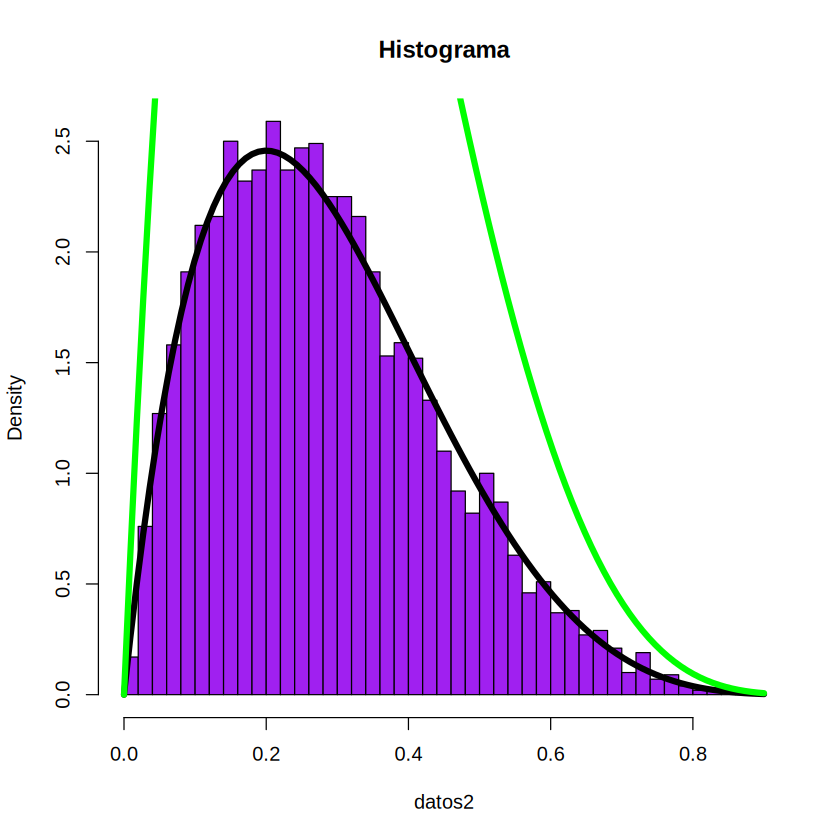

In [151]:


nsim = 5000
alpha = 2
beta = 5

x_star = (alpha - 1) / (alpha + beta - 2)
M = dbeta(x_star, shape1 = alpha, shape2 = beta)


genNorm2 = function(nsim,alpha,beta){
  X = numeric(nsim)
  k = 0
  j = 0
  while(k < nsim){
    Y = runif(1,0,1)
    U = runif(1,0,1)
    j = j + 1
    if(U <= dbeta(Y,shape1 = alpha,shape2 = beta)/M){
       k = k + 1
       X[k] = Y
    }
  }
  return(X)
}

datos2 = genNorm2(nsim,alpha,beta)


hist(datos2,freq = FALSE,breaks = "FD",col = "purple",main = "Histograma",)

curve(dbeta(x,shape1 = alpha,shape2 = beta),add = TRUE,lwd = 5,col = "black")

curve(M*dbeta(x,shape1 = alpha,shape2 = beta),add = TRUE,lwd = 5,col = "green")

shapiro.test(datos2)